In [57]:
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

# --- Reproducibility ---
# Setting a fixed seed means every time you run this notebook
# you get the SAME random numbers → same train/val/test split
# same weight initialization → fully reproducible results
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)          # Python's built-in random
    np.random.seed(seed)       # NumPy random
    torch.manual_seed(seed)    # PyTorch CPU random
    torch.cuda.manual_seed_all(seed)  # PyTorch GPU random
    torch.backends.cudnn.deterministic = True  # makes convolutions deterministic

set_seed()

# Use GPU if available, otherwise CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [58]:
# ---------------------------------------------------------------
# HYPERPARAMETERS — keep these IDENTICAL to your Task 2 notebook
# This is required by the assignment for fair comparison
# ---------------------------------------------------------------

DATA_DIR    = Path('/kaggle/input/datasets/fernando2rad/brain-tumor-mri-images-44c')
IMG_SIZE    = 224       # resize every image to 224×224 pixels
BATCH_SIZE  = 32        # 32 images processed at once during training
LR          = 1e-3      # learning rate = how big each weight update step is
NUM_EPOCHS  = 10        # maximum training rounds (increased to 50)
PATIENCE    = 5         # stop early if val loss doesn't improve for 5 epochs
TRAIN_SPLIT = 0.80      # 80% of data → training
VAL_SPLIT   = 0.10      # 10% → validation (monitor overfitting)
TEST_SPLIT  = 0.10      # 10% → final test (never seen during training)
WEIGHT_DECAY= 1e-4      # L2 regularization to prevent overfitting

# Auto-detect class folder names (glioma, meningioma, etc.)
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print(f'Number of classes : {NUM_CLASSES}')
print(f'Class names       : {CLASS_NAMES}')
print(f'Train/Val/Test    : {TRAIN_SPLIT}/{VAL_SPLIT}/{TEST_SPLIT}')
print(f'Max Epochs        : {NUM_EPOCHS}')

Number of classes : 44
Class names       : ['Astrocitoma T1', 'Astrocitoma T1C+', 'Astrocitoma T2', 'Carcinoma T1', 'Carcinoma T1C+', 'Carcinoma T2', 'Ependimoma T1', 'Ependimoma T1C+', 'Ependimoma T2', 'Ganglioglioma T1', 'Ganglioglioma T1C+', 'Ganglioglioma T2', 'Germinoma T1', 'Germinoma T1C+', 'Germinoma T2', 'Glioblastoma T1', 'Glioblastoma T1C+', 'Glioblastoma T2', 'Granuloma T1', 'Granuloma T1C+', 'Granuloma T2', 'Meduloblastoma T1', 'Meduloblastoma T1C+', 'Meduloblastoma T2', 'Meningioma T1', 'Meningioma T1C+', 'Meningioma T2', 'Neurocitoma T1', 'Neurocitoma T1C+', 'Neurocitoma T2', 'Oligodendroglioma T1', 'Oligodendroglioma T1C+', 'Oligodendroglioma T2', 'Papiloma T1', 'Papiloma T1C+', 'Papiloma T2', 'Schwannoma T1', 'Schwannoma T1C+', 'Schwannoma T2', 'Tuberculoma T1', 'Tuberculoma T1C+', 'Tuberculoma T2', '_NORMAL T1', '_NORMAL T2']
Train/Val/Test    : 0.8/0.1/0.1
Max Epochs        : 10


In [59]:

# ---------------------------------------------------------------
# TRANSFORMS
# Training data gets AUGMENTATION (artificial variations of images)
# This helps the model generalize — it won't just memorize training images
# ---------------------------------------------------------------

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # resize to 224×224
    transforms.RandomHorizontalFlip(p=0.5),    # flip image left-right (50% chance)
    transforms.RandomRotation(degrees=15),     # rotate up to ±15 degrees
    transforms.ColorJitter(brightness=0.2,     # randomly change brightness
                           contrast=0.2,       # and contrast slightly
                           saturation=0.1),
    transforms.RandomAffine(degrees=0,
                            translate=(0.05, 0.05)),  # shift image slightly
    transforms.ToTensor(),                     # convert PIL image → PyTorch tensor [0,1]
    transforms.Normalize(                      # normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],            # these values are standard practice
        std =[0.229, 0.224, 0.225])            # even for non-ImageNet datasets
])

# Val/Test images: NO augmentation — we want real, unmodified evaluation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# Load entire dataset from folder
# ImageFolder expects subfolders named by class (glioma/, meningioma/, etc.)
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)

# Calculate split sizes
n_total = len(full_dataset)
n_train = int(TRAIN_SPLIT * n_total)   # e.g. 70% of total
n_val   = int(VAL_SPLIT   * n_total)   # e.g. 15%
n_test  = n_total - n_train - n_val    # remaining 15%

# Randomly split into train / val / test subsets
# generator=... ensures same split every run (reproducibility)
train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply val/test transforms to val and test datasets
# (we override the transform only for these subsets)
val_ds.dataset  = datasets.ImageFolder(DATA_DIR, transform=val_test_transforms)
test_ds.dataset = datasets.ImageFolder(DATA_DIR, transform=val_test_transforms)

# DataLoaders batch the data and feed it to the model
# shuffle=True for training (randomize order each epoch)
# num_workers=2 → uses 2 background threads to load images faster
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Total images : {n_total}')
print(f'Training     : {n_train}')
print(f'Validation   : {n_val}')
print(f'Test         : {n_test}')

Total images : 4479
Training     : 3583
Validation   : 447
Test         : 449


In [60]:
# ---------------------------------------------------------------
# BUILDING THE CUSTOM CNN FROM SCRATCH
#
# A ConvBlock is the repeated unit of a CNN:
#   Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → MaxPool
#
# Conv2d:      scans the image with a small filter to detect features
#              (edges, textures, shapes)
# BatchNorm:   normalizes outputs so training is stable and faster
# ReLU:        activation function — sets negatives to 0 (adds non-linearity)
# MaxPool:     reduces spatial size by half (keeps strongest feature in region)
# ---------------------------------------------------------------

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        # in_ch  = number of input channels (e.g. 3 for RGB, 32 for next block)
        # out_ch = number of filters to learn (32, 64, 128, etc.)
        # pool   = whether to halve the spatial size with MaxPool
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            # kernel_size=3 → 3×3 filter slides over the image
            # padding=1 → adds 1 pixel border so output size matches input size
            # bias=False → BatchNorm handles the bias, so we don't need it here
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),   # inplace=True saves memory
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
            # kernel=2, stride=2 → cuts width and height in half
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    """
    Architecture overview:
    Input: (Batch, 3, 224, 224)   ← 3-channel RGB image
      Block 1: 3→32   + pool  → (B, 32,  112, 112)
      Block 2: 32→64  + pool  → (B, 64,   56,  56)
      Block 3: 64→128 + pool  → (B, 128,  28,  28)
      Block 4: 128→256+ pool  → (B, 256,  14,  14)
      Block 5: 256→512+ pool  → (B, 512,   7,   7)
      AdaptiveAvgPool          → (B, 512,   1,   1)
      Flatten                  → (B, 512)
      Linear 512→256 + ReLU
      Dropout
      Linear 256→num_classes   → final prediction
    """
    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()

        # Feature extractor: stacked ConvBlocks
        # Each block learns increasingly complex features:
        # Block1 = edges/corners, Block2 = textures, Block3+ = shapes/structures
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),
            ConvBlock(32,  64,  pool=True),
            ConvBlock(64,  128, pool=True),
            ConvBlock(128, 256, pool=True),
            ConvBlock(256, 512, pool=True),
        )

        # Reduces any spatial size to 1×1 (makes model flexible to image sizes)
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Classifier head: takes the 512 feature vector → class scores
        self.classifier = nn.Sequential(
            nn.Flatten(),             # (B,512,1,1) → (B,512)
            nn.Linear(512, 256),      # fully connected: 512 inputs → 256 outputs
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),      # randomly zeroes 50% of neurons during training
                                      # → prevents the model from memorizing training data
            nn.Linear(256, num_classes)  # final layer: 256 → number of cancer classes
        )

    def forward(self, x):
        x = self.features(x)    # extract features
        x = self.pool(x)        # global average pooling
        return self.classifier(x)  # classify


# Create model and send to GPU/CPU
model = CustomCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model architecture:\n{model}')
print(f'\nTotal trainable parameters: {total_params:,}')

Model architecture:
CustomCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (

In [61]:
# ---------------------------------------------------------------
# CrossEntropyLoss: standard loss for multi-class classification
#   It measures how wrong the model's predictions are
#   Lower loss = model is more confident and correct
#
# Adam optimizer: updates the model weights after each batch
#   It adapts the learning rate per parameter automatically
#   weight_decay adds L2 penalty → keeps weights small → less overfitting
#
# ReduceLROnPlateau scheduler:
#   If val loss doesn't improve for 3 epochs → halve the learning rate
#   This helps the model fine-tune more carefully later in training
# ---------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # we want to minimize val loss
    factor=0.5,       # multiply LR by 0.5 when triggered
    patience=3,       # wait 3 epochs before reducing
)

print('Loss, optimizer, and scheduler are ready.')

Loss, optimizer, and scheduler are ready.


In [62]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # we want to minimize val loss
    factor=0.5,       # new_lr = old_lr × 0.5 when triggered
    patience=3,       # wait 3 epochs of no improvement before reducing
)

print('Loss, optimizer, and scheduler are ready.')

# Optional: check your PyTorch version
print(f'PyTorch version: {torch.__version__}')

Loss, optimizer, and scheduler are ready.
PyTorch version: 2.10.0+cu128


In [63]:
# ---------------------------------------------------------------
# HELPER FUNCTIONS
# train_one_epoch: runs through all training batches once
# evaluate:        runs through val/test batches (no gradient updates)
# ---------------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()   # puts model in TRAINING mode (enables Dropout, BatchNorm updates)
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)    # move images to GPU
        labels = labels.to(DEVICE)  # move labels to GPU

        optimizer.zero_grad()       # clear gradients from previous batch

        outputs = model(imgs)       # forward pass: get predictions
        loss    = criterion(outputs, labels)  # calculate how wrong we are

        loss.backward()             # backpropagation: compute gradients
        optimizer.step()            # update weights using gradients

        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, correct / total   # avg loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()    # EVALUATION mode: disables Dropout, freezes BatchNorm
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():   # no gradient computation needed → saves memory & speed
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += imgs.size(0)

    return running_loss / total, correct / total


# ---------------------------------------------------------------
# MAIN TRAINING LOOP
# ---------------------------------------------------------------

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

best_val_loss    = float('inf')   # track best val loss (start at infinity)
patience_counter = 0              # counts epochs without improvement
best_model_path  = 'best_custom_cnn.pth'

train_start = time.time()   # record start time

for epoch in range(NUM_EPOCHS):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    v_loss, v_acc = evaluate(model, val_loader, criterion)

    scheduler.step(v_loss)   # possibly reduce LR

    # save to history for plotting later
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  '
          f'Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}')

    # --- Early Stopping ---
    # If val loss improved → save this model as the best one
    if v_loss < best_val_loss:
        best_val_loss    = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'  ✓ Best model saved (val_loss={v_loss:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{PATIENCE})')
        # Only stop if we've trained at least 5 epochs (assignment requirement)
        if patience_counter >= PATIENCE and epoch + 1 >= 5:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

train_time = time.time() - train_start
print(f'\nTotal Training Time: {train_time:.1f} seconds')

Epoch [01/10]  Train Loss: 3.3256  Train Acc: 0.1211  Val Loss: 3.2453  Val Acc: 0.1163
  ✓ Best model saved (val_loss=3.2453)
Epoch [02/10]  Train Loss: 2.9337  Train Acc: 0.1873  Val Loss: 2.9243  Val Acc: 0.1700
  ✓ Best model saved (val_loss=2.9243)
Epoch [03/10]  Train Loss: 2.7747  Train Acc: 0.2183  Val Loss: 3.0764  Val Acc: 0.1409
  No improvement (1/5)
Epoch [04/10]  Train Loss: 2.6149  Train Acc: 0.2470  Val Loss: 2.8599  Val Acc: 0.1946
  ✓ Best model saved (val_loss=2.8599)
Epoch [05/10]  Train Loss: 2.4712  Train Acc: 0.2724  Val Loss: 2.9626  Val Acc: 0.1834
  No improvement (1/5)
Epoch [06/10]  Train Loss: 2.3145  Train Acc: 0.3067  Val Loss: 2.0918  Val Acc: 0.3266
  ✓ Best model saved (val_loss=2.0918)
Epoch [07/10]  Train Loss: 2.1676  Train Acc: 0.3358  Val Loss: 1.9595  Val Acc: 0.3714
  ✓ Best model saved (val_loss=1.9595)
Epoch [08/10]  Train Loss: 2.1218  Train Acc: 0.3441  Val Loss: 2.0045  Val Acc: 0.3579
  No improvement (1/5)
Epoch [09/10]  Train Loss: 2.041

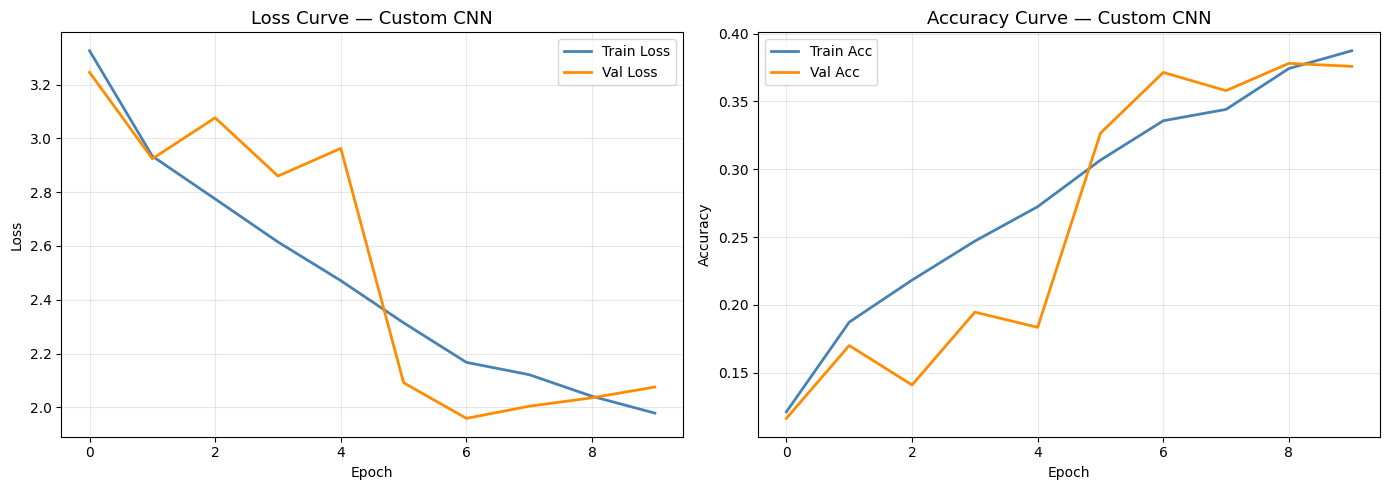

Saved: task3_learning_curves.png


In [64]:
# Visualize training progress
# If val_loss keeps going UP while train_loss goes DOWN → overfitting
# Good training: both curves go down together and converge

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue',  lw=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   color='darkorange', lw=2)
axes[0].set_title('Loss Curve — Custom CNN', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', color='steelblue',  lw=2)
axes[1].plot(history['val_acc'],   label='Val Acc',   color='darkorange', lw=2)
axes[1].set_title('Accuracy Curve — Custom CNN', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('task3_learning_curves.png', dpi=150)
plt.show()
print('Saved: task3_learning_curves.png')

In [65]:
# Load the BEST saved model (not the last epoch — the best val_loss epoch)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

model.eval()
all_preds, all_labels, all_probs = [], [], []

test_start = time.time()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(DEVICE)
        outputs = model(imgs)

        # softmax converts raw scores (logits) → probabilities that sum to 1
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()   # predicted class index

        all_probs.append(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_time  = time.time() - test_start
all_probs  = np.vstack(all_probs)   # shape: (num_test_samples, num_classes)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Compute all required metrics ---
acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
auc       = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
# OvR = One-vs-Rest: calculates AUC for each class against all others, then averages

print('='*55)
print('     TASK 3 — Custom CNN — Test Results')
print('='*55)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC (OvR) : {auc:.4f}')
print(f'  Train Time: {train_time:.1f}s')
print(f'  Test Time : {test_time:.4f}s')
print('='*55)
print('\nDetailed Per-Class Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

     TASK 3 — Custom CNN — Test Results
  Accuracy  : 0.3563  (35.63%)
  Precision : 0.2818
  Recall    : 0.3563
  F1-Score  : 0.2786
  AUC (OvR) : 0.9354
  Train Time: 253.0s
  Test Time : 1.9784s

Detailed Per-Class Report:
                        precision    recall  f1-score   support

        Astrocitoma T1       0.00      0.00      0.00        24
      Astrocitoma T1C+       0.19      0.24      0.21        17
        Astrocitoma T2       0.50      0.07      0.12        14
          Carcinoma T1       1.00      0.75      0.86         4
        Carcinoma T1C+       0.56      0.91      0.69        11
          Carcinoma T2       0.80      0.89      0.84         9
         Ependimoma T1       0.00      0.00      0.00         6
       Ependimoma T1C+       0.00      0.00      0.00         5
         Ependimoma T2       0.00      0.00      0.00         6
      Ganglioglioma T1       0.00      0.00      0.00         2
    Ganglioglioma T1C+       0.00      0.00      0.00         3
     

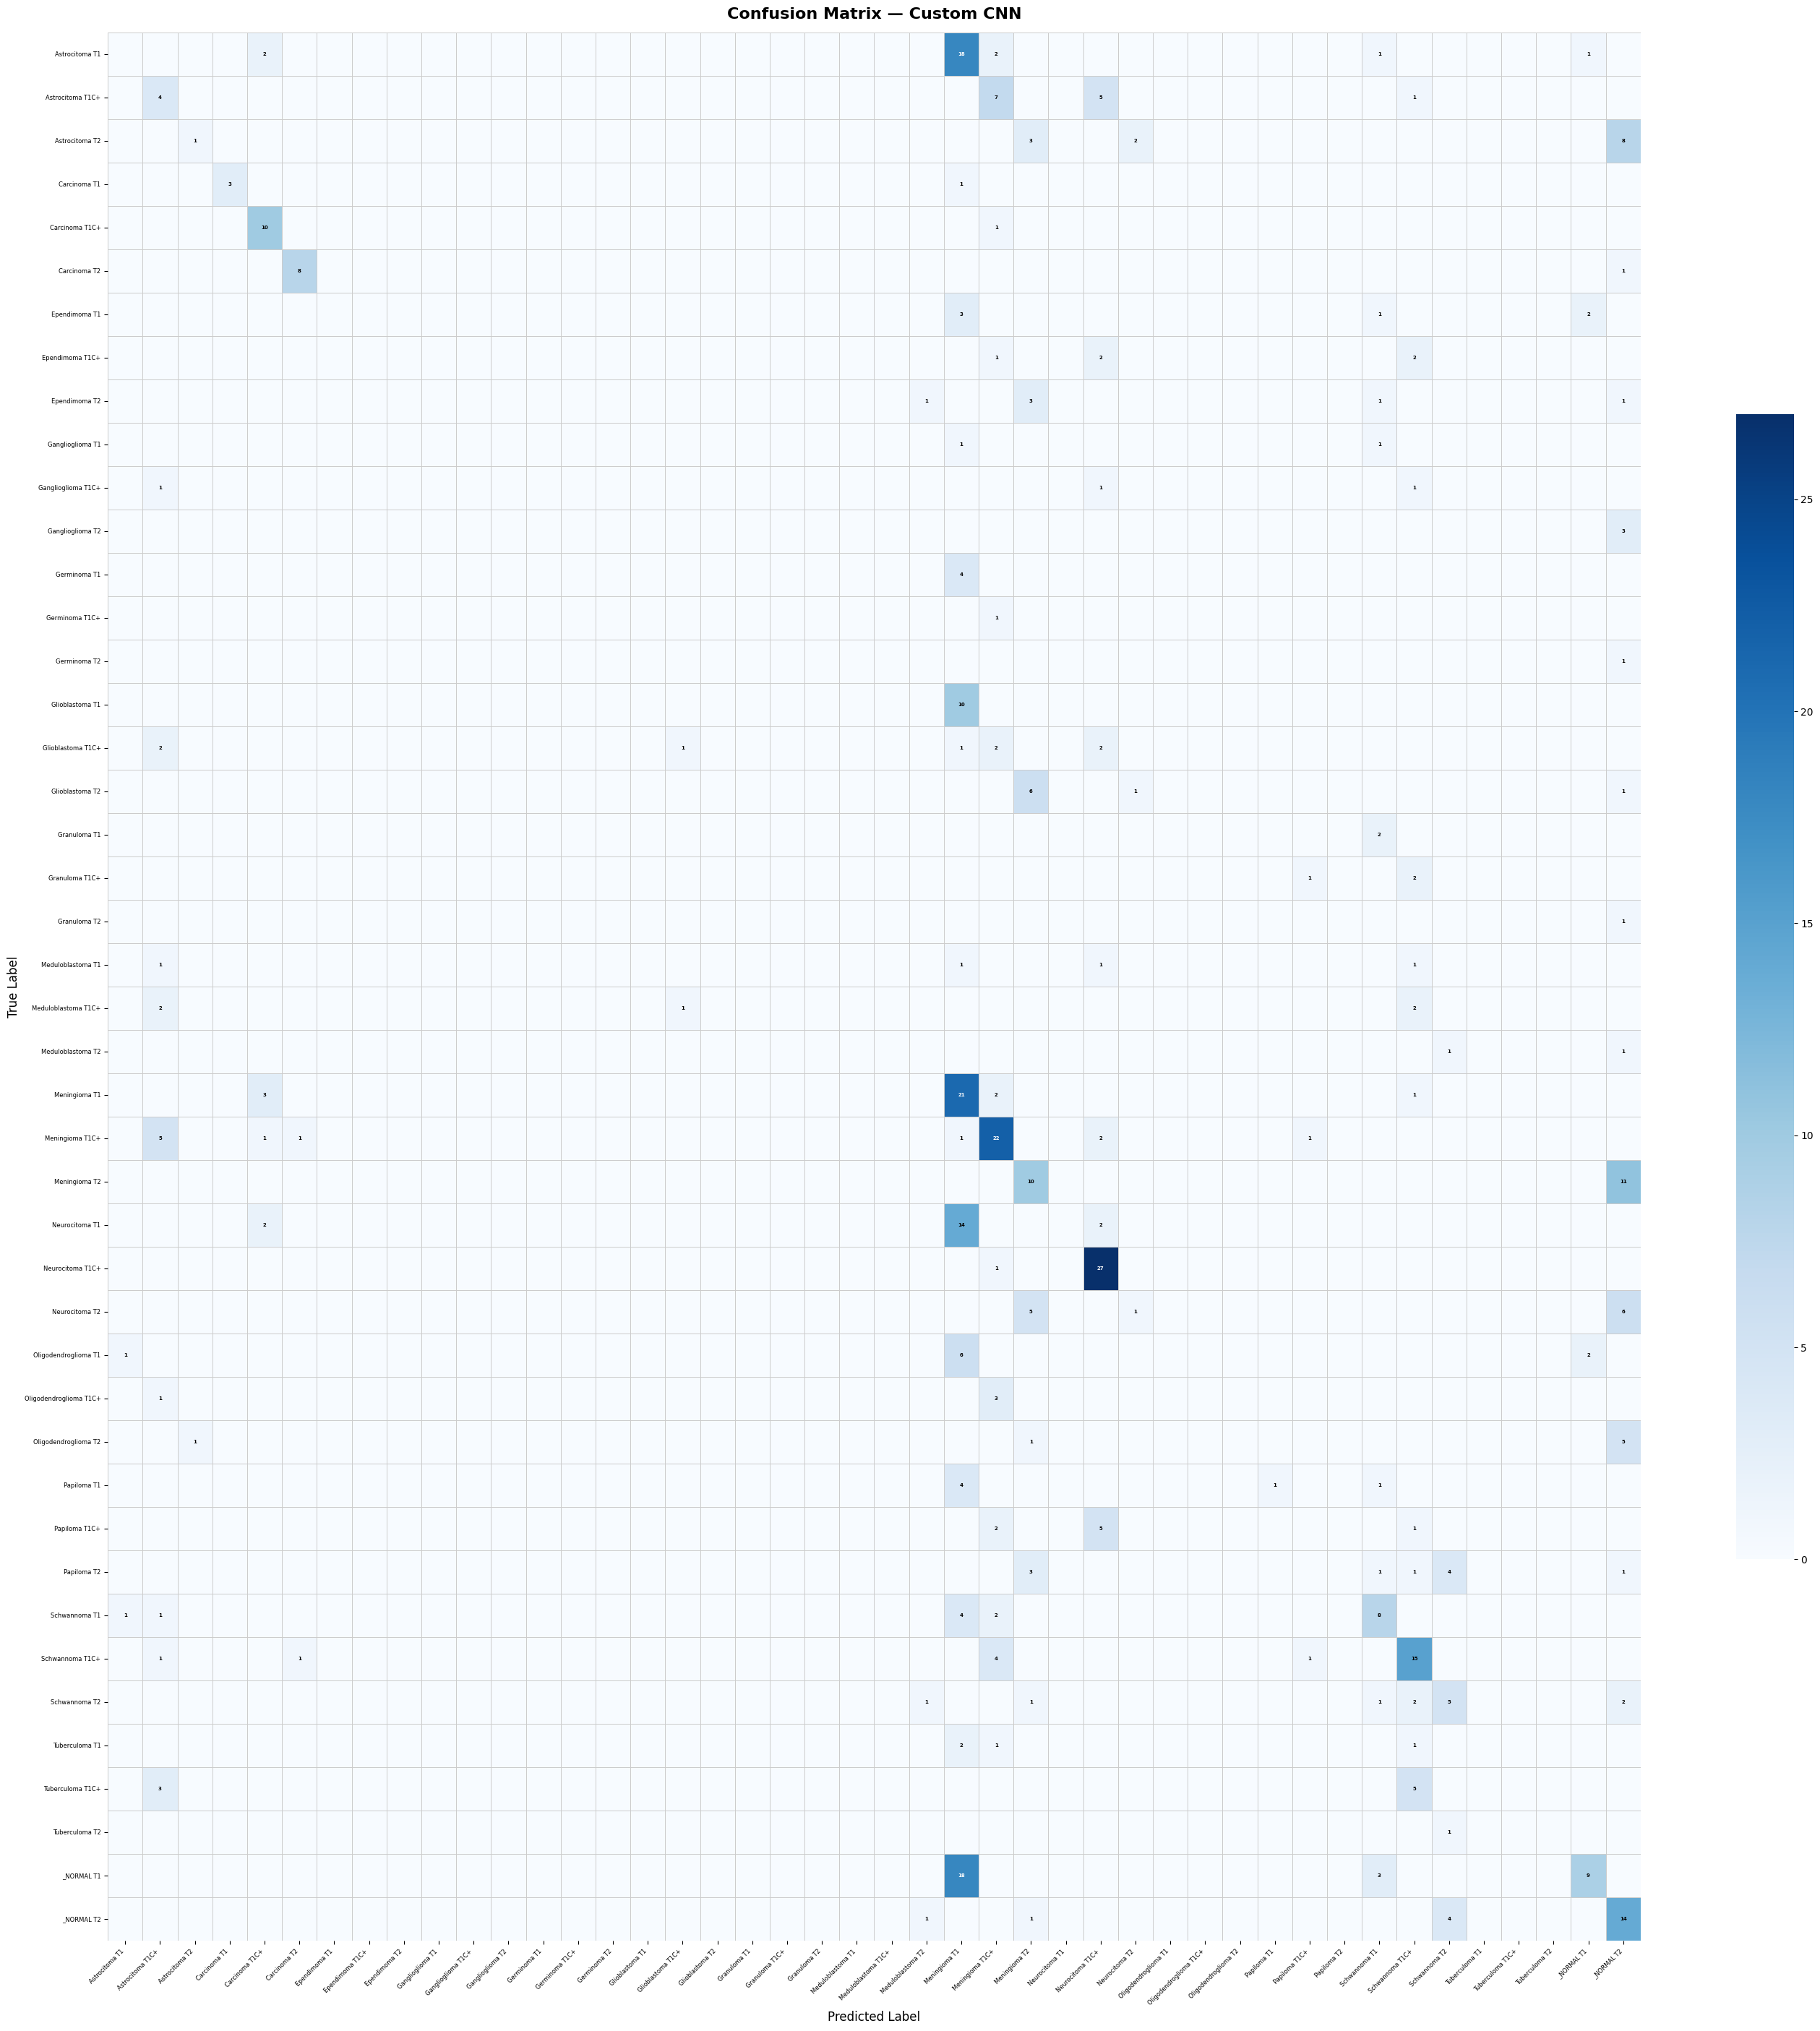

Saved: task3_confusion_matrix.png


In [66]:
cm = confusion_matrix(all_labels, all_preds)
n_cls = len(CLASS_NAMES)

# Dynamic figure size: give each class ~0.55 inches of space
cell_size = 0.55
fig_w = max(20, n_cls * cell_size + 4)
fig_h = max(16, n_cls * cell_size + 4)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# annot=False for large matrices → we draw text manually at a readable size
sns.heatmap(
    cm,
    annot=False,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.4,
    linecolor='#cccccc',
    ax=ax,
    cbar_kws={'shrink': 0.6}
)

# Annotate each cell manually so font size is readable
font_size = max(5, int(180 / n_cls))   # shrinks gracefully for many classes
for row in range(n_cls):
    for col in range(n_cls):
        val = cm[row, col]
        if val > 0:
            text_color = 'white' if val > cm.max() * 0.6 else 'black'
            ax.text(
                col + 0.5, row + 0.5, str(val),
                ha='center', va='center',
                fontsize=font_size, color=text_color, fontweight='bold'
            )

# Rotate x-axis labels so they don't pile on top of each other
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45, ha='right', fontsize=max(6, int(200 / n_cls))
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0, fontsize=max(6, int(200 / n_cls))
)

ax.set_title('Confusion Matrix — Custom CNN', fontsize=16, fontweight='bold', pad=14)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('task3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_confusion_matrix.png')

# How to read this:
# Diagonal cells = correct predictions
# Off-diagonal cells = mistakes (which class is confused with which)


# How to read this:
# Diagonal cells = correct predictions
# Off-diagonal cells = mistakes (which class is confused with which)


<Figure size 640x480 with 0 Axes>

Saved: task3_confusion_matrix.png


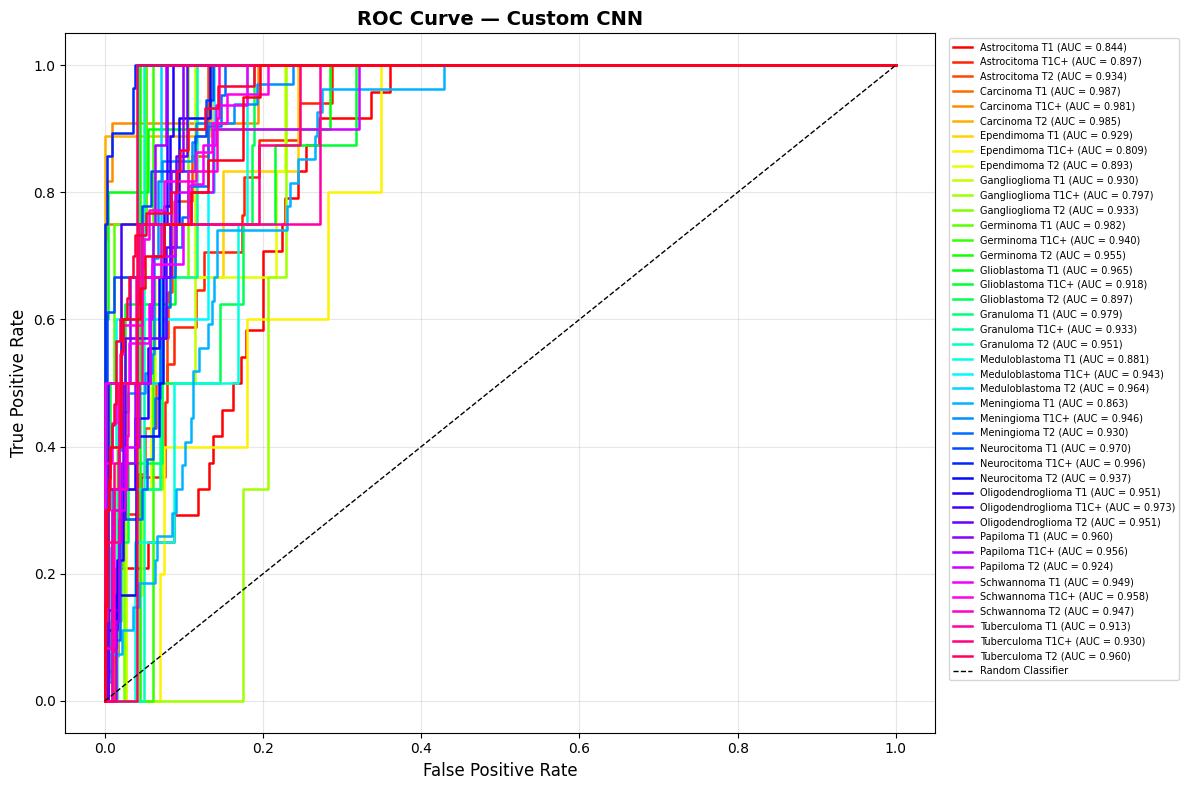

Saved: task3_roc_curve.png


In [67]:
# One-vs-Rest ROC curve: for each class, plot True Positive Rate vs False Positive Rate
# AUC = Area Under Curve — closer to 1.0 = better

# Rotate x-axis labels so they don't pile on top of each other
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45, ha='right', fontsize=max(6, int(200 / n_cls))
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0, fontsize=max(6, int(200 / n_cls))
)

ax.set_title('Confusion Matrix — Custom CNN', fontsize=16, fontweight='bold', pad=14)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('task3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_confusion_matrix.png')

# How to read this:
# Diagonal cells = correct predictions
# Off-diagonal cells = mistakes (which class is confused with which)






# One-vs-Rest ROC curve: for each class, plot True Positive Rate vs False Positive Rate
# AUC = Area Under Curve — closer to 1.0 = better

y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
# converts labels like [0,1,2,3,...] → one-hot matrix

# tab10 only has 10 colours — use a continuous colormap that scales to any N
cmap   = plt.cm.get_cmap('tab20' if NUM_CLASSES <= 20 else 'hsv', NUM_CLASSES)
colors = [cmap(i) for i in range(NUM_CLASSES)]   # list of (R,G,B,A) tuples

# Larger figure + legend outside the plot so nothing overlaps
fig, ax = plt.subplots(figsize=(12, 8))

for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_i       = roc_auc_score(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, color=colors[i], lw=1.8,
            label=f'{cls} (AUC = {auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Custom CNN', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# Place legend to the right of the plot so it never overlaps the curves
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    fontsize=7,
    framealpha=0.8,
    ncol=1
)

plt.tight_layout()
plt.savefig('task3_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_roc_curve.png')


In [68]:
import json

# Save predictions and metrics so Task 4 can compare against Task 3
task3_results = {
    'model'      : 'Custom CNN',
    'accuracy'   : float(acc),
    'precision'  : float(precision),
    'recall'     : float(recall),
    'f1'         : float(f1),
    'auc'        : float(auc),
    'train_time' : float(train_time),
    'test_time'  : float(test_time),
    'all_preds'  : all_preds.tolist(),
    'all_labels' : all_labels.tolist(),
    'all_probs'  : all_probs.tolist()
}

with open('task3_results.json', 'w') as f:
    json.dump(task3_results, f)

print('✓ Saved task3_results.json — use this in Task 4 for comparison!')

✓ Saved task3_results.json — use this in Task 4 for comparison!


## Grad-CAM — Visualizing What the Best Custom CNN Learned
We then overlay it on the original image for:
- ✅ **Correct predictions** — does the model focus on the tumour region?
- ❌ **Incorrect predictions** — is the model distracted by irrelevant areas?

In [69]:
# ---------------------------------------------------------------
# GRAD-CAM IMPLEMENTATION
#
# How it works:
#   1. Register forward hook  → capture the last conv-block's feature maps
#   2. Register backward hook → capture the gradients flowing back to those maps
#   3. For the predicted class, call loss.backward()
#   4. Global-average-pool the gradients → one weight per channel
#   5. Weighted sum of feature maps → raw CAM (can have negatives)
#   6. ReLU → keep only positive contributions
#   7. Resize CAM to 224×224 and overlay on the original image
# ---------------------------------------------------------------

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
import torch.nn.functional as F


class GradCAM:
    """
    Grad-CAM for any model where `target_layer` is a nn.Module.
    Usage:
        gcam = GradCAM(model, model.features[-1])
        cam  = gcam(img_tensor, class_idx=None)  # None → use predicted class
    """

    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self._fmaps       = None   # will hold forward feature maps
        self._grads       = None   # will hold backward gradients

        # Register hooks that fire automatically during forward / backward
        self._fwd_hook = target_layer.register_forward_hook(self._save_fmaps)
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_grads)

    def _save_fmaps(self, module, input, output):
        """Called automatically during model.forward()."""
        self._fmaps = output.detach()  # shape: (1, C, H, W)

    def _save_grads(self, module, grad_input, grad_output):
        """Called automatically during loss.backward()."""
        self._grads = grad_output[0].detach()  # shape: (1, C, H, W)

    def __call__(self, img_tensor, class_idx=None):
        """
        img_tensor : (1, 3, H, W) on DEVICE, requires no grad (we add it here)
        class_idx  : integer class to explain; None → use argmax (predicted class)
        Returns    : numpy array (H, W) in [0, 1] — the normalised CAM
        """
        self.model.eval()
        img_tensor = img_tensor.clone().requires_grad_(True).to(DEVICE)

        # Forward pass — hooks fire here
        logits     = self.model(img_tensor)              # (1, num_classes)
        pred_class = logits.argmax(dim=1).item()

        if class_idx is None:
            class_idx = pred_class

        # Backward pass for the target class — hooks fire here
        self.model.zero_grad()
        logits[0, class_idx].backward()

        # --- Compute CAM ---
        # Global average pool the gradients over spatial dims → (C,)
        weights = self._grads[0].mean(dim=(-2, -1))      # (C,)

        # Weighted sum of feature maps → (H_feat, W_feat)
        cam = (weights[:, None, None] * self._fmaps[0]).sum(dim=0)

        # ReLU: keep only activations that increase the class score
        cam = F.relu(cam)

        # Normalise to [0, 1]
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = torch.zeros_like(cam)   # flat map → model is indifferent

        return cam.cpu().numpy(), pred_class

    def remove_hooks(self):
        """Call this when done to free memory."""
        self._fwd_hook.remove()
        self._bwd_hook.remove()


# Attach Grad-CAM to the last ConvBlock of our CustomCNN
# model.features[-1] is ConvBlock(256→512) — deepest, most semantic layer
grad_cam = GradCAM(model, model.features[-1])
print('GradCAM attached to:', model.features[-1].__class__.__name__, '(last ConvBlock)')

GradCAM attached to: ConvBlock (last ConvBlock)


In [70]:
# ---------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------

def denorm(tensor):
    """
    Reverse ImageNet normalisation so we can display the image properly.
    tensor : (3, H, W) normalised → numpy (H, W, 3) in [0, 1]
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.cpu().numpy().transpose(1, 2, 0)  # CHW → HWC
    img  = std * img + mean                          # un-normalise
    return np.clip(img, 0, 1)                        # clamp to [0,1]


def overlay_cam(img_np, cam_np, alpha=0.45):
    """
    Resize cam_np to match img_np, convert to a colour heatmap,
    and blend with the original image.

    img_np : (H, W, 3) float in [0,1]
    cam_np : (h, w) float in [0,1]  (from GradCAM)
    alpha  : heatmap blend strength
    Returns: (H, W, 3) float in [0,1]
    """
    H, W = img_np.shape[:2]

    # Resize CAM to full image resolution
    cam_resized = cv2.resize(cam_np, (W, H))          # (H, W) float

    # Apply colour map: blue=cold (ignored), red=hot (attended)
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )                                                  # (H, W, 3) uint8 BGR
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) # → RGB
    heatmap  = heatmap.astype(np.float32) / 255.0

    # Blend
    overlay = alpha * heatmap + (1 - alpha) * img_np
    return np.clip(overlay, 0, 1)


print('Helper functions defined: denorm(), overlay_cam()')

Helper functions defined: denorm(), overlay_cam()


In [71]:
# ---------------------------------------------------------------
# COLLECT CORRECT AND INCORRECT SAMPLES FROM THE TEST SET
#
# We iterate through the test loader and store:
#   - correct_samples   : images the model got RIGHT
#   - incorrect_samples : images the model got WRONG
#
# We cap at MAX_SAMPLES per category so the visualisation stays
# readable (one row = one sample: original | Grad-CAM overlay).
# ---------------------------------------------------------------

MAX_SAMPLES = 4   # number of correct + incorrect examples to show

correct_samples   = []   # list of (img_tensor, true_label, pred_label)
incorrect_samples = []

model.eval()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_dev = imgs.to(DEVICE)
        outputs  = model(imgs_dev)
        preds    = outputs.argmax(dim=1).cpu()

        for i in range(len(labels)):
            true_lbl = labels[i].item()
            pred_lbl = preds[i].item()
            img_t    = imgs[i]          # (3, H, W) — still on CPU, normalised

            if true_lbl == pred_lbl and len(correct_samples) < MAX_SAMPLES:
                correct_samples.append((img_t, true_lbl, pred_lbl))

            if true_lbl != pred_lbl and len(incorrect_samples) < MAX_SAMPLES:
                incorrect_samples.append((img_t, true_lbl, pred_lbl))

        # Stop early once we have enough of both
        if (len(correct_samples) >= MAX_SAMPLES and
                len(incorrect_samples) >= MAX_SAMPLES):
            break

print(f'Collected {len(correct_samples)} correct  samples')
print(f'Collected {len(incorrect_samples)} incorrect samples')

Collected 4 correct  samples
Collected 4 incorrect samples


In [72]:
# ---------------------------------------------------------------
# GRAD-CAM VISUALISATION FUNCTION
#
# For each sample we show a 1×3 row:
#   [Original Image] [Grad-CAM Heatmap] [Overlay on Original]
#
# The title shows: True class | Predicted class | CORRECT / WRONG
# ---------------------------------------------------------------

def visualise_gradcam(samples, title_prefix, filename):
    """
    samples      : list of (img_tensor, true_label, pred_label)
    title_prefix : 'CORRECT' or 'INCORRECT'
    filename     : path to save the figure
    """
    n = len(samples)
    if n == 0:
        print(f'No {title_prefix} samples to display.')
        return

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    # Ensure axes is always 2D even when n=1
    if n == 1:
        axes = np.expand_dims(axes, 0)

    for row_idx, (img_t, true_lbl, pred_lbl) in enumerate(samples):
        # Compute Grad-CAM for the predicted class
        cam_np, _ = grad_cam(img_t.unsqueeze(0), class_idx=pred_lbl)

        img_np  = denorm(img_t)                       # original in [0,1]
        overlay = overlay_cam(img_np, cam_np)         # blended image

        # Heatmap alone (colourised, for reference)
        cam_colour = cv2.applyColorMap(
            np.uint8(255 * cv2.resize(cam_np, (IMG_SIZE, IMG_SIZE))),
            cv2.COLORMAP_JET
        )
        cam_colour = cv2.cvtColor(cam_colour, cv2.COLOR_BGR2RGB)

        correct_str = '✅ CORRECT' if true_lbl == pred_lbl else '❌ WRONG'
        true_name   = CLASS_NAMES[true_lbl]
        pred_name   = CLASS_NAMES[pred_lbl]

        # --- Column 0: Original ---
        axes[row_idx, 0].imshow(img_np)
        axes[row_idx, 0].set_title(f'Original\nTrue: {true_name}', fontsize=10)
        axes[row_idx, 0].axis('off')

        # --- Column 1: Grad-CAM heatmap ---
        axes[row_idx, 1].imshow(cam_colour)
        axes[row_idx, 1].set_title(f'Grad-CAM Heatmap\nPred: {pred_name}', fontsize=10)
        axes[row_idx, 1].axis('off')

        # --- Column 2: Overlay ---
        axes[row_idx, 2].imshow(overlay)
        colour = 'green' if true_lbl == pred_lbl else 'red'
        axes[row_idx, 2].set_title(
            f'Overlay — {correct_str}\nTrue: {true_name} | Pred: {pred_name}',
            fontsize=10, color=colour
        )
        axes[row_idx, 2].axis('off')

    fig.suptitle(
        f'Grad-CAM Visualisation — {title_prefix} Predictions',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')


print('visualise_gradcam() defined — ready to plot.')

visualise_gradcam() defined — ready to plot.


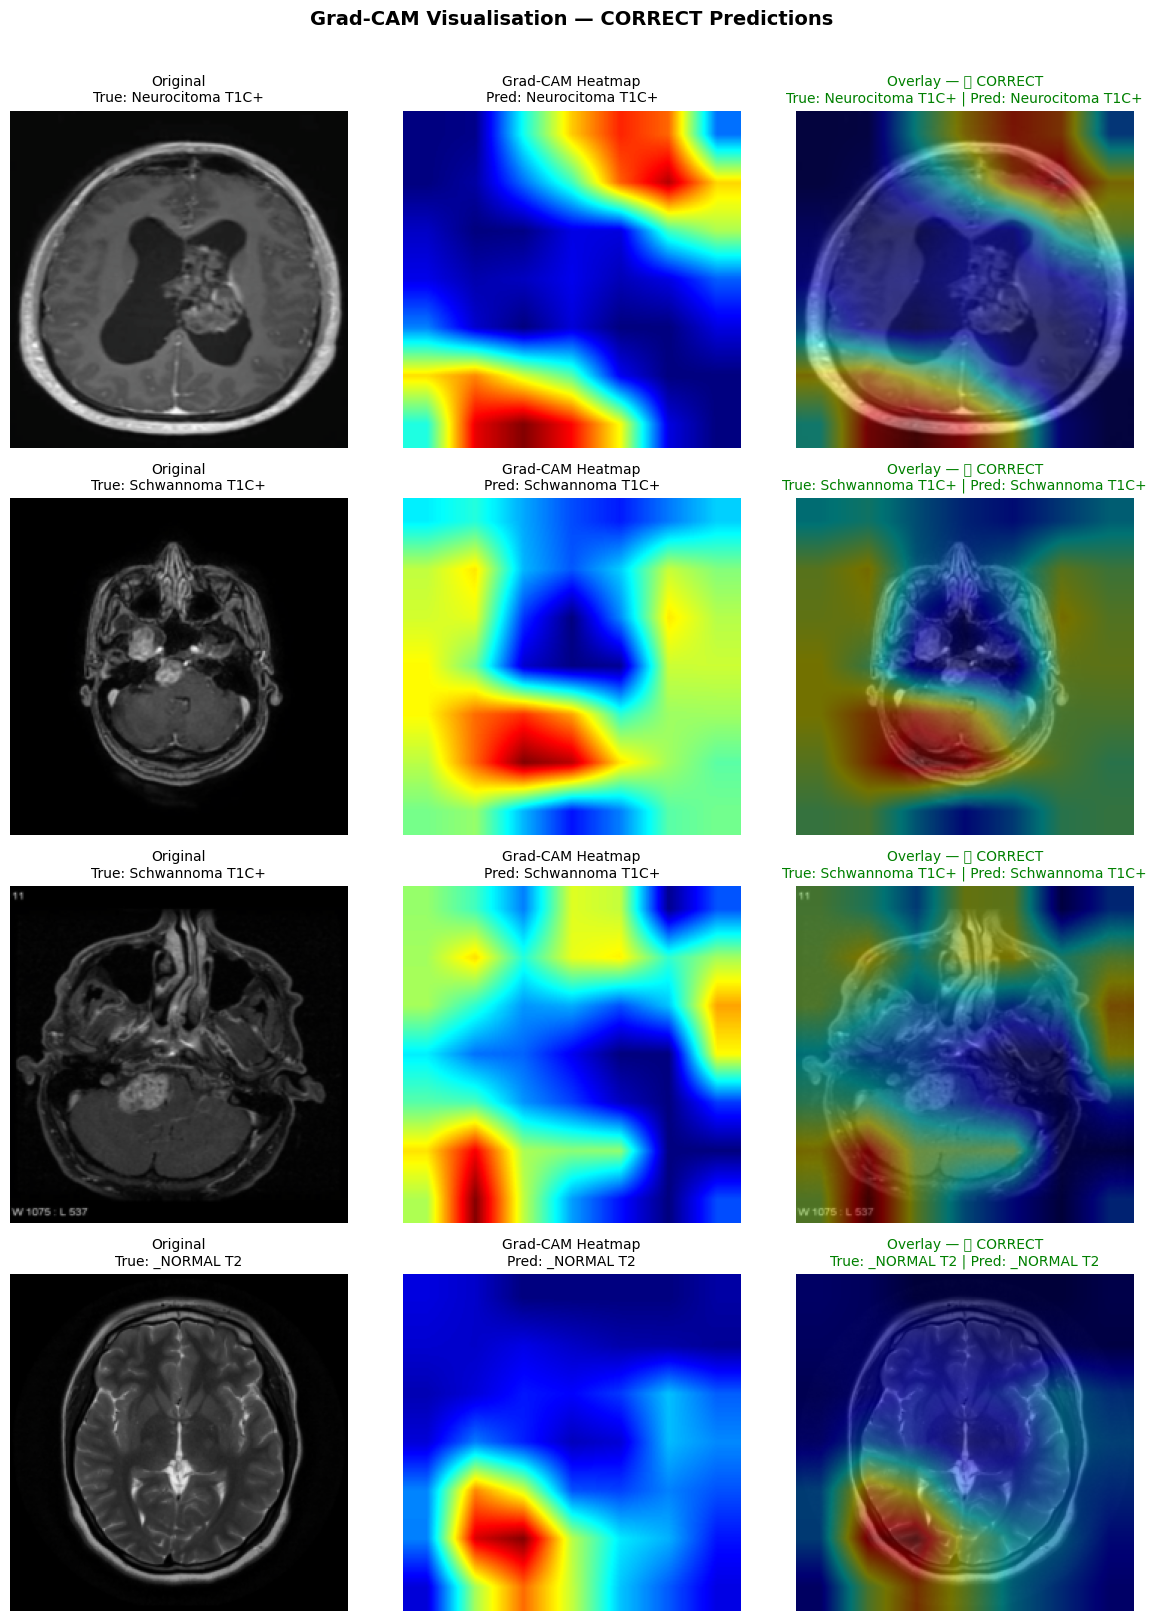

Saved: task3_gradcam_correct.png


In [73]:
# ---------------------------------------------------------------
# PLOT 1 — Correct Predictions
#
# For correct predictions the heatmap should ideally highlight the
# tumour/pathological region, showing the model has learned clinically
# relevant features rather than background artefacts.
# ---------------------------------------------------------------

visualise_gradcam(
    correct_samples,
    title_prefix='CORRECT',
    filename='task3_gradcam_correct.png'
)

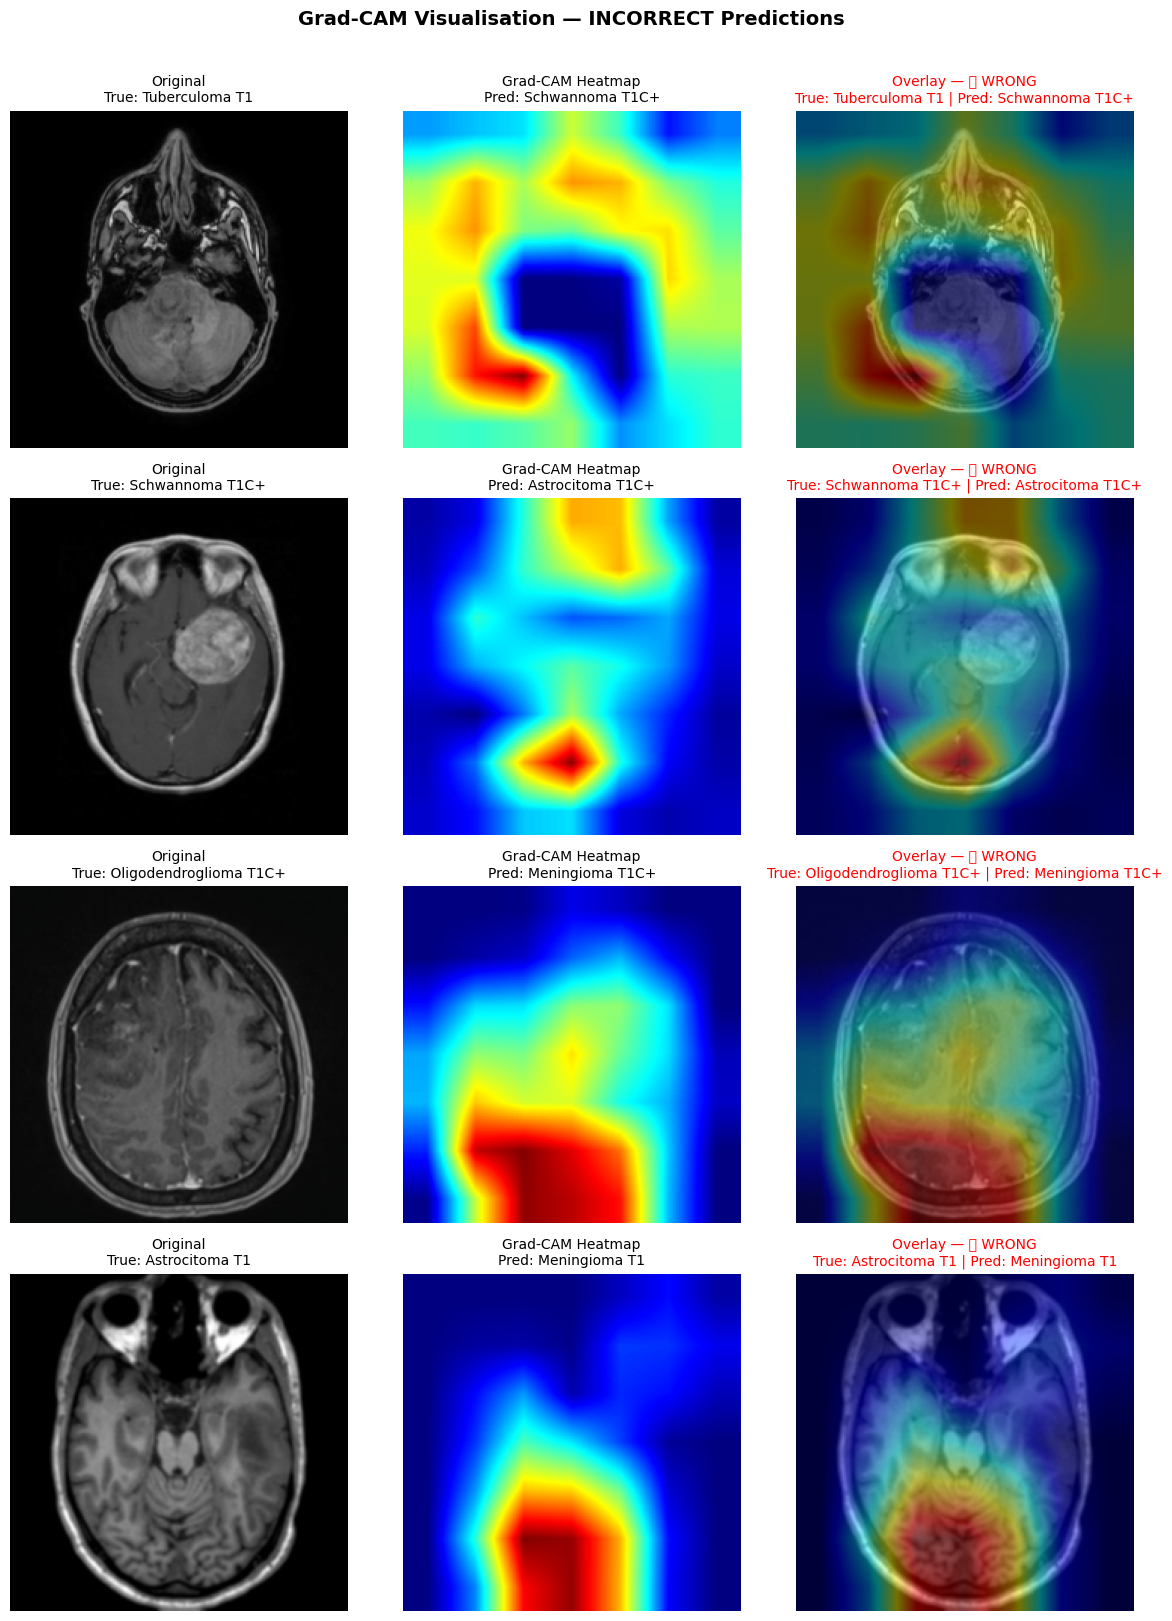

Saved: task3_gradcam_incorrect.png


In [74]:
# ---------------------------------------------------------------
# PLOT 2 — Incorrect Predictions
#
# For incorrect predictions the heatmap often reveals the model is
# focusing on the WRONG region (e.g., skull boundary, background
# noise) rather than the actual tumour, explaining the mistake.
# ---------------------------------------------------------------

visualise_gradcam(
    incorrect_samples,
    title_prefix='INCORRECT',
    filename='task3_gradcam_incorrect.png'
)

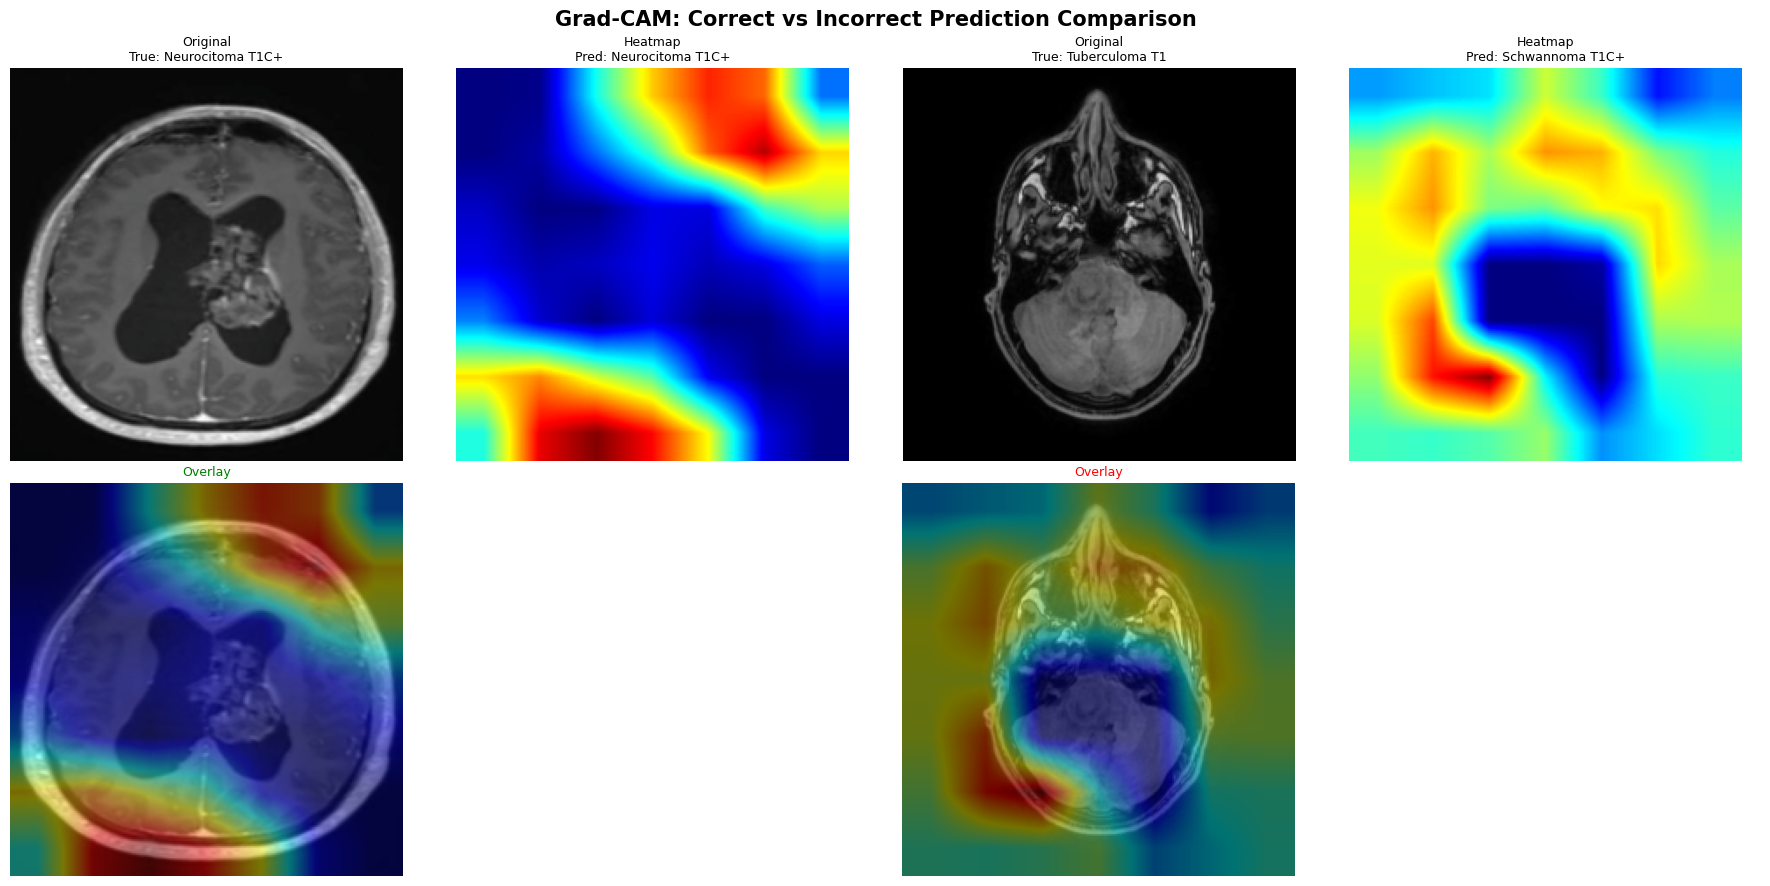

Saved: task3_gradcam_comparison.png


In [75]:
# ---------------------------------------------------------------
# PLOT 3 — Side-by-Side Comparison: Correct vs Incorrect
#
# Two columns: best correct sample (left) vs worst incorrect (right)
# Each column: Original → Heatmap → Overlay
# ---------------------------------------------------------------

if correct_samples and incorrect_samples:

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    def fill_column(axes_row0, axes_row1, sample, label_str, title_colour):
        img_t, true_lbl, pred_lbl = sample
        cam_np, _ = grad_cam(img_t.unsqueeze(0), class_idx=pred_lbl)
        img_np    = denorm(img_t)
        overlay   = overlay_cam(img_np, cam_np)
        cam_col   = cv2.cvtColor(
            cv2.applyColorMap(
                np.uint8(255 * cv2.resize(cam_np, (IMG_SIZE, IMG_SIZE))),
                cv2.COLORMAP_JET
            ), cv2.COLOR_BGR2RGB
        )
        true_name = CLASS_NAMES[true_lbl]
        pred_name = CLASS_NAMES[pred_lbl]

        axes_row0[0].imshow(img_np);    axes_row0[0].set_title(f'Original\nTrue: {true_name}', fontsize=9)
        axes_row0[1].imshow(cam_col);   axes_row0[1].set_title(f'Heatmap\nPred: {pred_name}',  fontsize=9)
        axes_row1[0].imshow(overlay);   axes_row1[0].set_title('Overlay', fontsize=9, color=title_colour)

        for ax in [axes_row0[0], axes_row0[1], axes_row1[0]]:
            ax.axis('off')

        axes_row0[0].set_ylabel(label_str, fontsize=11, fontweight='bold', color=title_colour)

    # Left two columns  → correct
    fill_column(axes[0, :2], axes[1, :2], correct_samples[0],   '✅ CORRECT',   'green')
    # Right two columns → incorrect
    fill_column(axes[0, 2:], axes[1, 2:], incorrect_samples[0], '❌ INCORRECT', 'red')

    # Hide the unused overlay axes (axes_row1[1]) for both halves
    axes[1, 1].axis('off')
    axes[1, 3].axis('off')

    fig.suptitle(
        'Grad-CAM: Correct vs Incorrect Prediction Comparison',
        fontsize=15, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('task3_gradcam_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: task3_gradcam_comparison.png')
else:
    print('Need at least 1 correct and 1 incorrect sample for comparison plot.')

In [76]:
# Release hooks to free GPU memory
grad_cam.remove_hooks()
print('Grad-CAM hooks removed.')
print('\nFiles saved:')
print('  task3_gradcam_correct.png    — heatmaps for correctly classified images')
print('  task3_gradcam_incorrect.png  — heatmaps for misclassified images')
print('  task3_gradcam_comparison.png — side-by-side correct vs incorrect')

Grad-CAM hooks removed.

Files saved:
  task3_gradcam_correct.png    — heatmaps for correctly classified images
  task3_gradcam_incorrect.png  — heatmaps for misclassified images
  task3_gradcam_comparison.png — side-by-side correct vs incorrect


### Grad-CAM Interpretation Guide

| Colour in heatmap | Meaning |
|---|---|
| 🔴 Red / Yellow | High attention — model focuses here |
| 🔵 Blue | Low attention — model ignores this region |

**Correct predictions:** The red/yellow region should align with the tumour mass or
surrounding tissue abnormalities — evidence the model learned clinically relevant
features.

**Incorrect predictions:** The activated region often falls on the skull boundary,
dark background, or an unrelated anatomical structure — revealing why the model was
confused and what kind of additional data augmentation or architecture changes could
help.
